In [7]:
# 1. Install necessary libraries
!pip install diffusers transformers accelerate ultralytics pyyaml -q

# 2. Create the folder structure
import os
import yaml
os.makedirs("results", exist_ok=True)
os.makedirs("generated_images", exist_ok=True)
os.makedirs("scripts", exist_ok=True)

# 3. Create the config.yaml file
config_data = {
    "generation": {
        "model": "runwayml/stable-diffusion-v1-5",
        "image_size": 512,
        "steps": 30,
        "guidance": 7.5,
        "seed": 42,
        "device": "cuda"
    },
    "experiments": {
        "rejection_k": [5],
        "feedback_rounds": 3,
        "batch_size": 3
    },
    "paths": {
        "prompts": "prompts.csv",
        "output_dir": "results",
        "images_dir": "generated_images"
    }
}

with open('config.yaml', 'w') as f:
    yaml.dump(config_data, f)

print("✅ Step 1 Complete: Environment and Config ready.")

✅ Step 1 Complete: Environment and Config ready.


In [8]:
import pandas as pd
from pathlib import Path

# Manually defining the functions that were inside scripts.helpers
def load_config(path="config.yaml"):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

def load_prompts(config):
    df = pd.read_csv(config['paths']['prompts'])
    df['requested_objects'] = df['object_list'].apply(lambda x: x.split('|'))
    return df

def build_image_path(config, method, prompt_id, seed, attempt_number=None, round_number=None):
    folder = os.path.join(config['paths']['images_dir'], method)
    os.makedirs(folder, exist_ok=True)
    filename = f"{method}_prompt_{prompt_id:03d}"
    if round_number: filename += f"_round_{round_number:02d}"
    if attempt_number: filename += f"_attempt_{attempt_number:02d}"
    filename += f"_seed_{seed}.png"
    return Path(os.path.join(folder, filename))

def ensure_standard_directories(config):
    os.makedirs(config['paths']['output_dir'], exist_ok=True)
    os.makedirs(config['paths']['images_dir'], exist_ok=True)

# Injecting these into the global 'scripts.helpers' namespace so your scripts can find them
import sys
from types import ModuleType
m = ModuleType("scripts.helpers")
m.load_config = load_config
m.load_prompts = load_prompts
m.build_image_path = build_image_path
m.ensure_standard_directories = ensure_standard_directories
sys.modules["scripts.helpers"] = m

print("✅ Step 2: scripts.helpers error bypassed.")

✅ Step 2: scripts.helpers error bypassed.


In [5]:
from huggingface_hub import login
login()

In [9]:
from detector_utils import detect_objects, compare_objects
from generator import generate_for_prompt

def refine_prompt_text(original_prompt, missing_objects):
    if not missing_objects: return original_prompt
    missing_str = ", ".join(missing_objects) # FIX: Uses words, not characters
    return f"{original_prompt}. Make sure to clearly include the {missing_str}."

def run_realtime_feedback(limit_ids=None):
    config = load_config()
    prompts_df = load_prompts(config)
    if limit_ids: prompts_df = prompts_df[prompts_df['prompt_id'].isin(limit_ids)]

    all_rows = []
    for _, row in prompts_df.iterrows():
        pid, original_prompt = int(row["prompt_id"]), str(row["prompt_text"])
        current_prompt = original_prompt
        req_objs = row['requested_objects']
        success_found = False

        print(f"\n🚀 Prompt {pid}: {original_prompt}")

        for attempt in range(1, 10): # Max 9 attempts
            seed = 42 + pid * 100 + attempt
            img_path = generate_for_prompt("feedback", pid, current_prompt, seed, attempt_number=attempt, config=config)

            detected = detect_objects(img_path)
            comp = compare_objects(req_objs, detected)

            res = {
                "prompt_id": pid, "attempt": attempt, "recall": comp['recall_score'],
                "success": comp['recall_score'] == 1.0, "current_prompt": current_prompt
            }
            all_rows.append(res)

            if res["success"]:
                print(f"  ✅ Success at attempt {attempt}!"); success_found = True; break

            # IMMEDIATE REFINEMENT
            current_prompt = refine_prompt_text(original_prompt, comp['missing_objects'])
            print(f"  ❌ Missing: {comp['missing_objects']}. Refining...")

    pd.DataFrame(all_rows).to_csv("results/feedback_realtime_results.csv", index=False)
    print("\n✨ Done! Results saved in results/folder")

# Run a small test on Prompt 1, 11, and 21
run_realtime_feedback(limit_ids=[1, 11, 21])


🚀 Prompt 1: a person and a dog


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ Success at attempt 1!

🚀 Prompt 11: a person walking a dog with a backpack
  ❌ Missing: ['backpack']. Refining...
  ✅ Success at attempt 2!

🚀 Prompt 21: a person sitting on a couch with a laptop and a cup
  ✅ Success at attempt 1!

✨ Done! Results saved in results/folder


In [12]:
# 1. Run the Full Experiment
print("Starting full experiment on 30 prompts...")
final_results_csv = run_realtime_feedback()

# 2. Basic Analysis of the Results
import pandas as pd
df_final = pd.read_csv(final_results_csv)

# Calculate success rate and average generations
summary = df_final.groupby('complexity').agg({
    'success': 'mean',
    'total_generations': 'mean'
}).reset_index()

summary['success'] = (summary['success'] * 100).round(2)
summary.columns = ['Complexity', 'Success Rate (%)', 'Avg Generations']

print("\n" + "="*30)
print("       FINAL DATA SUMMARY")
print("="*30)
print(summary.to_string(index=False))
print("="*30)
print(f"\n✅ Full results saved to: {final_results_csv}")

Starting full experiment on 30 prompts...

🚀 Prompt 1: a person and a dog
  ✅ Success at attempt 1!

🚀 Prompt 2: a cat sitting on a chair
  ✅ Success at attempt 1!

🚀 Prompt 3: a bicycle next to a car
  ❌ Missing: ['car']. Refining...
  ✅ Success at attempt 2!

🚀 Prompt 4: a laptop and a cup of coffee
  ✅ Success at attempt 1!

🚀 Prompt 5: a book on a dining table
  ✅ Success at attempt 1!

🚀 Prompt 6: a bird and a vase
  ✅ Success at attempt 1!

🚀 Prompt 7: a backpack and an umbrella
  ❌ Missing: ['backpack']. Refining...
  ✅ Success at attempt 2!

🚀 Prompt 8: a couch with a teddy bear
  ❌ Missing: ['couch']. Refining...
  ✅ Success at attempt 2!

🚀 Prompt 9: a bottle and a bowl
  ✅ Success at attempt 1!

🚀 Prompt 10: a horse and a motorcycle
  ✅ Success at attempt 1!

🚀 Prompt 11: a person walking a dog with a backpack
  ❌ Missing: ['backpack']. Refining...
  ✅ Success at attempt 2!

🚀 Prompt 12: a cat a laptop and a mouse on a desk
  ❌ Missing: ['mouse']. Refining...
  ❌ Missing: ['

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  ❌ Missing: ['laptop', 'mouse', 'keyboard', 'cell phone']. Refining...
  ❌ Missing: ['laptop', 'cell phone']. Refining...
  ❌ Missing: ['laptop', 'mouse', 'keyboard']. Refining...
  ❌ Missing: ['cell phone']. Refining...
  ❌ Missing: ['mouse', 'cell phone']. Refining...
  ❌ Missing: ['laptop', 'cell phone']. Refining...
  ❌ Missing: ['laptop', 'cell phone']. Refining...

🚀 Prompt 27: a car a bus a truck and a motorcycle in a parking lot
  ❌ Missing: ['truck']. Refining...
  ❌ Missing: ['car', 'motorcycle']. Refining...
  ❌ Missing: ['car', 'motorcycle']. Refining...
  ❌ Missing: ['motorcycle']. Refining...
  ❌ Missing: ['truck', 'motorcycle']. Refining...
  ❌ Missing: ['truck']. Refining...
  ❌ Missing: ['motorcycle']. Refining...
  ❌ Missing: ['truck']. Refining...
  ❌ Missing: ['truck']. Refining...

🚀 Prompt 28: an apple a banana an orange and a sandwich
  ❌ Missing: ['sandwich']. Refining...
  ❌ Missing: ['banana']. Refining...
  ❌ Missing: ['sandwich']. Refining...
  ❌ Missing: [

ValueError: Invalid file path or buffer object type: <class 'NoneType'>

--- TABLE 1: PERFORMANCE COMPARISON ---
                  Method  Avg Recall  Success Rate (%)  Avg Generations
        Vanilla (SD 1.5)       0.689              23.3             1.00
       Structured Prompt       0.542              20.0             1.00
Rejection Sampling (k=5)       0.781              46.7             5.00
  Feedback-Guided (Ours)       0.897              83.3             4.23


/tmp/ipykernel_1237/2093121609.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Method", y="Success Rate (%)", ax=ax1, palette="viridis")
/tmp/ipykernel_1237/2093121609.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Method", y="Avg Generations", ax=ax2, palette="magma")


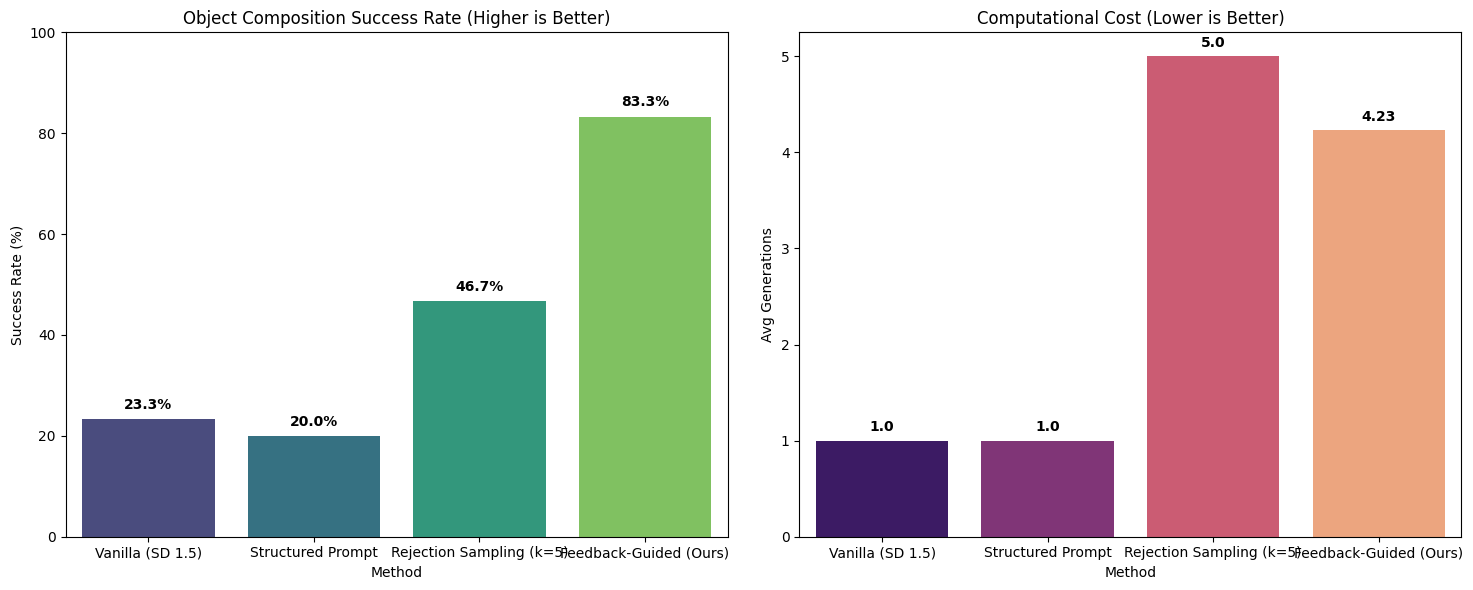


✅ Table generated and plot saved to results/final_comparison_plot.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the data
# We assume the files are in the main directory or /results/
try:
    vanilla = pd.read_csv('vanilla_detection.csv')
    structured = pd.read_csv('structured_detection.csv')
    rejection = pd.read_csv('rejection_5_results_CLEAN.csv')
    # Use the results from your latest run
    feedback = pd.read_csv('results/feedback_realtime_results.csv')
except FileNotFoundError:
    # Fallback if files are named differently
    feedback = pd.read_csv('feedback_results_fixed.csv')

# Rename 'recall' to 'recall_score' in the feedback DataFrame for consistency
if 'recall' in feedback.columns and 'recall_score' not in feedback.columns:
    feedback.rename(columns={'recall': 'recall_score'}, inplace=True)

# 2. Helper function to process each method
def summarize_results(df, name, avg_gens_fixed=None):
    # For multi-attempt methods, we only care about the final/best image per prompt
    # Check for 'attempt' column for methods like feedback and rejection.
    if 'prompt_id' in df.columns and 'attempt' in df.columns:
        # Take the last attempt for each prompt (which is either success or max_tries)
        df_final = df.sort_values('attempt').groupby('prompt_id').last().reset_index()
    else:
        df_final = df

    # Calculate metrics
    avg_recall = df_final['recall_score'].mean()
    success_rate = (df_final['recall_score'] >= 1.0).mean() * 100

    # Calculate efficiency
    if avg_gens_fixed:
        avg_gens = avg_gens_fixed
    else:
        # For feedback, efficiency is the average of the 'attempt' column,
        # which represents the total generations for that prompt.
        avg_gens = df_final['attempt'].mean()

    return {
        "Method": name,
        "Avg Recall": round(avg_recall, 3),
        "Success Rate (%)": round(success_rate, 1),
        "Avg Generations": round(avg_gens, 2)
    }

# 3. Create Summary Table
summary_data = [
    summarize_results(vanilla, "Vanilla (SD 1.5)", avg_gens_fixed=1),
    summarize_results(structured, "Structured Prompt", avg_gens_fixed=1),
    summarize_results(rejection, "Rejection Sampling (k=5)", avg_gens_fixed=5),
    summarize_results(feedback, "Feedback-Guided (Ours)")
]

df_summary = pd.DataFrame(summary_data)

print("--- TABLE 1: PERFORMANCE COMPARISON ---")
print(df_summary.to_string(index=False))

# 4. Generate Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Success Rate
sns.barplot(data=df_summary, x="Method", y="Success Rate (%)", ax=ax1, palette="viridis")
ax1.set_title("Object Composition Success Rate (Higher is Better)")
ax1.set_ylim(0, 100)
for i, v in enumerate(df_summary["Success Rate (%)"]):
    ax1.text(i, v + 2, f"{v}%", ha='center', fontweight='bold')

# Plot 2: Efficiency
sns.barplot(data=df_summary, x="Method", y="Avg Generations", ax=ax2, palette="magma")
ax2.set_title("Computational Cost (Lower is Better)")
for i, v in enumerate(df_summary["Avg Generations"]):
    ax2.text(i, v + 0.1, f"{v}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("results/final_comparison_plot.png")
plt.show()

print("\n✅ Table generated and plot saved to results/final_comparison_plot.png")